In [47]:
!pip install pandas numpy matplotlib seaborn scipy scikit-learn statsmodels joblib streamlit

In [48]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

Data Loading and load three dataset                  




link for dataset local goverment elections 2016 and local goverment elections 2021: https://results.elections.org.za/home/downloads/me-results

for dataset 3 : https://results.elections.org.za/home/downloads/mbe-results



Cleaning and fixing of dataset 1

In [49]:
d2016 = pd.read_excel("local goverment elections 2016.xls",skiprows=17)

WARNING *** file size (24448) not 512 + multiple of sector size (512)


In [50]:
d2016.head()

,Unnamed: 0,Unnamed: 1,Unnamed: 2,Unnamed: 3,Total \nValid \nVotes,% Total\nValid \nVotes,Unnamed: 6,Unnamed: 7,Total \nValid \nVotes.1,% Total\nValid \nVotes.1,Unnamed: 10,Total \nValid \nVotes.2,% Total\nValid \nVotes.2,Unnamed: 13,Unnamed: 14,Total \nValid \nVotes.3,% Total\nValid \nVotes.3,Total \nValid \nVotes.4,% Total\nValid \nVotes.4
0,NaN,ACADEMIC CONGRESS UNION,NaN,NaN,439.0,0.000392,NaN,NaN,486,0.00044,NaN,925,0.000416,NaN,NaN,-,-,925.0,0.000416
1,NaN,AFRICAN CHRISTIAN DEMOCRATIC PARTY,NaN,NaN,6147.0,0.005483,NaN,NaN,5956,0.005392,NaN,12103,0.005438,NaN,NaN,-,-,12103.0,0.005438
2,NaN,AFRICAN INDEPENDENT CONGRESS,NaN,NaN,13772.0,0.012285,NaN,NaN,16673,0.015095,NaN,30445,0.013679,NaN,NaN,-,-,30445.0,0.013679
3,NaN,AFRICAN MANTUNGWA COMMUNITY,NaN,NaN,1469.0,0.001310,NaN,NaN,1935,0.001752,NaN,3404,0.001529,NaN,NaN,-,-,3404.0,0.001529
4,NaN,AFRICAN NATIONAL CONGRESS,NaN,NaN,593621.0,0.529521,NaN,NaN,652891,0.591091,NaN,1246512,0.560078,NaN,NaN,-,-,1246512.0,0.560078


In [75]:
print("Number of rows:", len(d2016))
print("Number of columns:", len(d2016.columns))

print("\nColumns:")
print(d2016.columns.tolist())

Number of rows: 32
Number of columns: 19

Columns:
['Unnamed: 0', 'Unnamed: 1', 'Unnamed: 2', 'Unnamed: 3', 'Total \nValid \nVotes', '% Total\nValid \nVotes', 'Unnamed: 6', 'Unnamed: 7', 'Total \nValid \nVotes.1', '% Total\nValid \nVotes.1', 'Unnamed: 10', 'Total \nValid \nVotes.2', '% Total\nValid \nVotes.2', 'Unnamed: 13', 'Unnamed: 14', 'Total \nValid \nVotes.3', '% Total\nValid \nVotes.3', 'Total \nValid \nVotes.4', '% Total\nValid \nVotes.4']


In [76]:
print(d2016.head(15).to_string())

    Unnamed: 0                          Unnamed: 1  Unnamed: 2  Unnamed: 3  Total \nValid \nVotes  % Total\nValid \nVotes  Unnamed: 6  Unnamed: 7 Total \nValid \nVotes.1 % Total\nValid \nVotes.1  Unnamed: 10  Total \nValid \nVotes.2  % Total\nValid \nVotes.2  Unnamed: 13  Unnamed: 14 Total \nValid \nVotes.3 % Total\nValid \nVotes.3  Total \nValid \nVotes.4  % Total\nValid \nVotes.4
0          NaN             ACADEMIC CONGRESS UNION         NaN         NaN                  439.0                0.000392         NaN         NaN                     486                  0.00044          NaN                      925                  0.000416          NaN          NaN                       -                        -                    925.0                  0.000416
1          NaN  AFRICAN CHRISTIAN DEMOCRATIC PARTY         NaN         NaN                 6147.0                0.005483         NaN         NaN                    5956                 0.005392          NaN                    121

In [77]:
for i, col in enumerate(d2016.columns):
    print(i, repr(col))

0 'Unnamed: 0'
1 'Unnamed: 1'
2 'Unnamed: 2'
3 'Unnamed: 3'
4 'Total \nValid \nVotes'
5 '% Total\nValid \nVotes'
6 'Unnamed: 6'
7 'Unnamed: 7'
8 'Total \nValid \nVotes.1'
9 '% Total\nValid \nVotes.1'
10 'Unnamed: 10'
11 'Total \nValid \nVotes.2'
12 '% Total\nValid \nVotes.2'
13 'Unnamed: 13'
14 'Unnamed: 14'
15 'Total \nValid \nVotes.3'
16 '% Total\nValid \nVotes.3'
17 'Total \nValid \nVotes.4'
18 '% Total\nValid \nVotes.4'


In [78]:
d2016_clean = d2016.iloc[:, [
    1,   # Party Name
    4,   # Ward
    8,   # PR
    11,  # Ward + PR
    15,  # DC 40%
    17   # Total - All Ballots
]].copy()

d2016_clean.columns = [
    'Party Name',
    'Ward',
    'PR',
    'Total_Ward_PR',
    'DC_40',
    'Total_All_Ballots'
]

print(d2016_clean.head(50))

                            Party Name       Ward       PR  Total_Ward_PR  \
0              ACADEMIC CONGRESS UNION      439.0      486            925   
1   AFRICAN CHRISTIAN DEMOCRATIC PARTY     6147.0     5956          12103   
2         AFRICAN INDEPENDENT CONGRESS    13772.0    16673          30445   
3          AFRICAN MANTUNGWA COMMUNITY     1469.0     1935           3404   
4            AFRICAN NATIONAL CONGRESS   593621.0   652891        1246512   
5          AFRICAN PEOPLE'S CONVENTION     1695.0     2922           4617   
6                           AL JAMA-AH     2284.0     2003           4287   
7           ALLIED MOVEMENT FOR CHANGE     1023.0      860           1883   
8        AZANIAN PEOPLE'S ORGANISATION      413.0      476            889   
9              CONGRESS  OF THE PEOPLE      709.0     1566           2275   
10                 DEMOCRATIC ALLIANCE   294867.0   304206         599073   
11         DEMOCRATIC LIBERAL CONGRESS     6714.0     4801          11515   

Cleaning and fixing of dataset 2

In [69]:
import pandas as pd

d2021 = pd.read_excel(
    "local goverment elections 2021.xls",
    skiprows=17
)

print("Number of rows:", len(d2021))
print("Number of columns:", len(d2021.columns))

print("\nColumns:")
print(d2021.columns.tolist())

WARNING *** file size (32704) not 512 + multiple of sector size (512)
Number of rows: 58
Number of columns: 19

Columns:
['Unnamed: 0', 'Unnamed: 1', 'Unnamed: 2', 'Unnamed: 3', 'Total \nValid \nVotes', '% Total\nValid \nVotes', 'Unnamed: 6', 'Unnamed: 7', 'Total \nValid \nVotes.1', '% Total\nValid \nVotes.1', 'Unnamed: 10', 'Total \nValid \nVotes.2', '% Total\nValid \nVotes.2', 'Unnamed: 13', 'Unnamed: 14', 'Total \nValid \nVotes.3', '% Total\nValid \nVotes.3', 'Total \nValid \nVotes.4', '% Total\nValid \nVotes.4']


In [70]:
print(d2021.head(15).to_string())

    Unnamed: 0                          Unnamed: 1  Unnamed: 2  Unnamed: 3  Total \nValid \nVotes  % Total\nValid \nVotes  Unnamed: 6  Unnamed: 7 Total \nValid \nVotes.1 % Total\nValid \nVotes.1  Unnamed: 10  Total \nValid \nVotes.2  % Total\nValid \nVotes.2  Unnamed: 13  Unnamed: 14 Total \nValid \nVotes.3 % Total\nValid \nVotes.3  Total \nValid \nVotes.4  % Total\nValid \nVotes.4
0          NaN               ABANTU BATHO CONGRESS         NaN         NaN                 5866.0                0.007559         NaN         NaN                    4998                 0.006451          NaN                    10864                  0.007006          NaN          NaN                       -                        -                  10864.0                  0.007006
1          NaN             ACADEMIC CONGRESS UNION         NaN         NaN                  289.0                0.000372         NaN         NaN                     379                 0.000489          NaN                      6

In [71]:
for i, col in enumerate(d2021.columns):
    print(i, repr(col))

0 'Unnamed: 0'
1 'Unnamed: 1'
2 'Unnamed: 2'
3 'Unnamed: 3'
4 'Total \nValid \nVotes'
5 '% Total\nValid \nVotes'
6 'Unnamed: 6'
7 'Unnamed: 7'
8 'Total \nValid \nVotes.1'
9 '% Total\nValid \nVotes.1'
10 'Unnamed: 10'
11 'Total \nValid \nVotes.2'
12 '% Total\nValid \nVotes.2'
13 'Unnamed: 13'
14 'Unnamed: 14'
15 'Total \nValid \nVotes.3'
16 '% Total\nValid \nVotes.3'
17 'Total \nValid \nVotes.4'
18 '% Total\nValid \nVotes.4'


In [74]:
d2021_clean = d2021.iloc[:, [
    1,   # Party Name
    4,   # Ward
    8,   # PR
    11,  # Ward + PR
    15,  # DC 40%
    17   # Total - All Ballots
]].copy()

d2021_clean.columns = [
    'Party Name',
    'Ward',
    'PR',
    'Total_Ward_PR',
    'DC_40',
    'Total_All_Ballots'
]

print(d2021_clean.head(50))

                            Party Name      Ward      PR  Total_Ward_PR DC_40  \
0                ABANTU BATHO CONGRESS    5866.0    4998          10864     -   
1              ACADEMIC CONGRESS UNION     289.0     379            668     -   
2                             ACTIONSA   11663.0   18201          29864     -   
3            ACTIVE CITIZENS COALITION    8025.0    6239          14264     -   
4   ACTIVISTS MOVEMENT OF SOUTH AFRICA     917.0     603           1520     -   
5            ADVANCED DYNAMIC ALLIANCE     486.0     481            967     -   
6          AFRICA RESTORATION ALLIANCE     352.0     203            555     -   
7            AFRICAN BASIC REPUBLICANS       0.0     207            207     -   
8   AFRICAN CHRISTIAN DEMOCRATIC PARTY    6022.0    5893          11915     -   
9            AFRICAN DEMOCRATIC CHANGE    4328.0    3507           7835     -   
10          AFRICAN FEDERAL CONVENTION      64.0     323            387     -   
11          AFRICAN FREEDOM 

Cleaning and fixing of dataset 3


In [56]:
d2024 = pd.read_excel("2024 National & Provincial Elections.xls",skiprows=17)

WARNING *** file size (24512) not 512 + multiple of sector size (512)


In [58]:
d2024.head()

,Unnamed: 0,Unnamed: 1,Unnamed: 2,Unnamed: 3,Unnamed: 4,Unnamed: 5,Unnamed: 6,Unnamed: 7,Unnamed: 8,Unnamed: 9,Unnamed: 10,Unnamed: 11,Unnamed: 12,Unnamed: 13,Unnamed: 14,Unnamed: 15,Unnamed: 16,Unnamed: 17
0,NaN,Party Name,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Abbr.,NaN,No. of Votes,% Votes
1,NaN,ABANTU BATHO CONGRESS,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,ABC,NaN,584,0.000473
2,NaN,ACTIONSA,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,ACTIONSA,NaN,5953,0.00482
3,NaN,AFRICA AFRICANS RECLAIM,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,AAR,NaN,145,0.000117
4,NaN,AFRICA RESTORATION ALLIANCE,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,ARA,NaN,437,0.000354


In [79]:
d2024 = pd.read_excel(
    "2024 National & Provincial Elections.xls",
    skiprows=17
)

print("Number of rows:", d2024.shape[0])
print("Number of columns:", d2024.shape[1])

for i, col in enumerate(d2024.columns):
    print(i, repr(col))

WARNING *** file size (24512) not 512 + multiple of sector size (512)
Number of rows: 40
Number of columns: 18
0 'Unnamed: 0'
1 'Unnamed: 1'
2 'Unnamed: 2'
3 'Unnamed: 3'
4 'Unnamed: 4'
5 'Unnamed: 5'
6 'Unnamed: 6'
7 'Unnamed: 7'
8 'Unnamed: 8'
9 'Unnamed: 9'
10 'Unnamed: 10'
11 'Unnamed: 11'
12 'Unnamed: 12'
13 'Unnamed: 13'
14 'Unnamed: 14'
15 'Unnamed: 15'
16 'Unnamed: 16'
17 'Unnamed: 17'


In [80]:
print(d2024.head(10).to_string())

   Unnamed: 0                          Unnamed: 1  Unnamed: 2  Unnamed: 3  Unnamed: 4  Unnamed: 5  Unnamed: 6  Unnamed: 7  Unnamed: 8  Unnamed: 9  Unnamed: 10  Unnamed: 11  Unnamed: 12  Unnamed: 13 Unnamed: 14  Unnamed: 15   Unnamed: 16 Unnamed: 17
0         NaN                          Party Name         NaN         NaN         NaN         NaN         NaN         NaN         NaN         NaN          NaN          NaN          NaN          NaN       Abbr.          NaN  No. of Votes     % Votes
1         NaN               ABANTU BATHO CONGRESS         NaN         NaN         NaN         NaN         NaN         NaN         NaN         NaN          NaN          NaN          NaN          NaN         ABC          NaN           584    0.000473
2         NaN                            ACTIONSA         NaN         NaN         NaN         NaN         NaN         NaN         NaN         NaN          NaN          NaN          NaN          NaN    ACTIONSA          NaN          5953     0.00482
3   

In [81]:
d2024_clean = d2024.iloc[1:, [1, 14, 16, 17]].copy()

d2024_clean.columns = [
    'Party Name',
    'Abbreviation',
    'Votes',
    'Percentage'
]

# Reset the index
d2024_clean.reset_index(drop=True, inplace=True)

print(d2024_clean.head(10).to_string())

                           Party Name Abbreviation   Votes Percentage
0               ABANTU BATHO CONGRESS          ABC     584   0.000473
1                            ACTIONSA     ACTIONSA    5953    0.00482
2             AFRICA AFRICANS RECLAIM          AAR     145   0.000117
3         AFRICA RESTORATION ALLIANCE          ARA     437   0.000354
4  AFRICAN CHRISTIAN DEMOCRATIC PARTY         ACDP    5753   0.004659
5           AFRICAN MOVEMENT CONGRESS      NO_ABBR     908   0.000735
6           AFRICAN NATIONAL CONGRESS          ANC  180355   0.146044
7         AFRICAN PEOPLE'S CONVENTION          APC     393   0.000318
8           AFRICAN PEOPLE'S MOVEMENT        APEMO     174   0.000141
9     AFRICAN TRANSFORMATION MOVEMENT          ATM    2956   0.002394


In [82]:
print("Rows:", d2024_clean.shape[0])
print("Columns:", d2024_clean.shape[1])

print("\nMissing values:")
print(d2024_clean.isnull().sum())

print("\nData types:")
print(d2024_clean.dtypes)

Rows: 39
Columns: 4

Missing values:
Party Name      0
Abbreviation    3
Votes           0
Percentage      2
dtype: int64

Data types:
Party Name      object
Abbreviation    object
Votes           object
Percentage      object
dtype: object


FIX 2016 CLEAN DATASET

In [83]:
print("=== 2016 CLEAN BEFORE FIXING ===")
print(d2016_clean.dtypes)
print(d2016_clean.isnull().sum())
print(d2016_clean.head(3))

=== 2016 CLEAN BEFORE FIXING ===
Party Name            object
Ward                 float64
PR                    object
Total_Ward_PR          int64
DC_40                 object
Total_All_Ballots    float64
dtype: object
Party Name           0
Ward                 1
PR                   1
Total_Ward_PR        0
DC_40                1
Total_All_Ballots    1
dtype: int64
                           Party Name     Ward     PR  Total_Ward_PR DC_40  \
0             ACADEMIC CONGRESS UNION    439.0    486            925     -   
1  AFRICAN CHRISTIAN DEMOCRATIC PARTY   6147.0   5956          12103     -   
2        AFRICAN INDEPENDENT CONGRESS  13772.0  16673          30445     -   

   Total_All_Ballots  
0              925.0  
1            12103.0  
2            30445.0  


Convert numeric columns

In [84]:
d2016_clean["Ward"] = pd.to_numeric(d2016_clean["Ward"], errors="coerce")
d2016_clean["PR"] = pd.to_numeric(d2016_clean["PR"], errors="coerce")
d2016_clean["Total_Ward_PR"] = pd.to_numeric(d2016_clean["Total_Ward_PR"], errors="coerce")
d2016_clean["DC_40"] = pd.to_numeric(d2016_clean["DC_40"], errors="coerce")
d2016_clean["Total_All_Ballots"] = pd.to_numeric(d2016_clean["Total_All_Ballots"], errors="coerce")

Replace "-" with NaN then fill with 0

In [85]:
d2016_clean = d2016_clean.replace("-", np.nan)

Separate the summary rows (Total Valid Votes, Total Spoilt Votes, etc.) from the party rows

In [87]:
summary_rows_2016 = d2016_clean[
    d2016_clean["Party Name"].astype(str).str.contains("Total", case=False, na=False)
].copy()

party_rows_2016 = d2016_clean[
    ~d2016_clean["Party Name"].astype(str).str.contains("Total", case=False, na=False)
].copy()

# Fill NaN votes with 0 for party rows (means party did not contest that ballot type)

In [88]:
for col in ["Ward", "PR", "Total_Ward_PR", "Total_All_Ballots"]:
    party_rows_2016[col] = party_rows_2016[col].fillna(0)

print("Party rows 2016:", party_rows_2016.shape)
print("Summary rows 2016:")
print(summary_rows_2016[["Party Name", "Total_All_Ballots"]])

Party rows 2016: (28, 6)
Summary rows 2016:
             Party Name  Total_All_Ballots
28    Total Valid Votes          2225605.0
29   Total Spoilt Votes            50276.0
30     Total Votes Cast          2275881.0
31  Total Voter Turnout                NaN


FIX 2021 CLEAN DATASET

In [89]:
print("=== 2021 CLEAN BEFORE FIXING ===")
print(d2021_clean.dtypes)
print(d2021_clean.isnull().sum())
print(d2021_clean.head(3))

=== 2021 CLEAN BEFORE FIXING ===
Party Name            object
Ward                 float64
PR                    object
Total_Ward_PR          int64
DC_40                 object
Total_All_Ballots    float64
dtype: object
Party Name           0
Ward                 1
PR                   1
Total_Ward_PR        0
DC_40                1
Total_All_Ballots    1
dtype: int64
                Party Name     Ward     PR  Total_Ward_PR DC_40  \
0    ABANTU BATHO CONGRESS   5866.0   4998          10864     -   
1  ACADEMIC CONGRESS UNION    289.0    379            668     -   
2                 ACTIONSA  11663.0  18201          29864     -   

   Total_All_Ballots  
0            10864.0  
1              668.0  
2            29864.0  


Convert numeric columns

In [90]:
d2021_clean["Ward"] = pd.to_numeric(d2021_clean["Ward"], errors="coerce")
d2021_clean["PR"] = pd.to_numeric(d2021_clean["PR"], errors="coerce")
d2021_clean["Total_Ward_PR"] = pd.to_numeric(d2021_clean["Total_Ward_PR"], errors="coerce")
d2021_clean["DC_40"] = pd.to_numeric(d2021_clean["DC_40"], errors="coerce")
d2021_clean["Total_All_Ballots"] = pd.to_numeric(d2021_clean["Total_All_Ballots"], errors="coerce")

Replace "-" with NaN

In [91]:
d2021_clean = d2021_clean.replace("-", np.nan)

Separate summary rows from party rows

In [92]:
summary_rows_2021 = d2021_clean[
    d2021_clean["Party Name"].astype(str).str.contains("Total", case=False, na=False)
].copy()

party_rows_2021 = d2021_clean[
    ~d2021_clean["Party Name"].astype(str).str.contains("Total", case=False, na=False)
].copy()

Fill NaN votes with 0

In [94]:
for col in ["Ward", "PR", "Total_Ward_PR", "Total_All_Ballots"]:
    party_rows_2021[col] = party_rows_2021[col].fillna(0)

print("Party rows 2021:", party_rows_2021.shape)
print("Summary rows 2021:")
print(summary_rows_2021[["Party Name", "Total_All_Ballots"]])

Party rows 2021: (54, 6)
Summary rows 2021:
             Party Name  Total_All_Ballots
54    Total Valid Votes          1550751.0
55   Total Spoilt Votes            32590.0
56     Total Votes Cast          1583341.0
57  Total Voter Turnout                NaN


FIX 2024 CLEAN DATASET

In [95]:
print("=== 2024 CLEAN BEFORE FIXING ===")
print(d2024_clean.dtypes)
print(d2024_clean.isnull().sum())
print(d2024_clean.head(3))

=== 2024 CLEAN BEFORE FIXING ===
Party Name      object
Abbreviation    object
Votes           object
Percentage      object
dtype: object
Party Name      0
Abbreviation    3
Votes           0
Percentage      2
dtype: int64
                Party Name Abbreviation Votes Percentage
0    ABANTU BATHO CONGRESS          ABC   584   0.000473
1                 ACTIONSA     ACTIONSA  5953    0.00482
2  AFRICA AFRICANS RECLAIM          AAR   145   0.000117


Convert Votes and Percentage to numeric

In [96]:
d2024_clean["Votes"] = pd.to_numeric(d2024_clean["Votes"], errors="coerce")
d2024_clean["Percentage"] = pd.to_numeric(d2024_clean["Percentage"], errors="coerce")

Drop the two summary rows that snuck in (Total Valid Votes, Spoilt Votes, Total Votes Cast)

In [97]:
d2024_clean = d2024_clean[
    ~d2024_clean["Party Name"].astype(str).str.contains("Total", case=False, na=False)
].copy()

Reset index

In [98]:
d2024_clean = d2024_clean.reset_index(drop=True)

Fill missing abbreviation

In [99]:
d2024_clean["Abbreviation"] = d2024_clean["Abbreviation"].fillna("NO_ABBR")

Fill missing percentage by recomputing from votes

In [101]:
total_votes_2024 = d2024_clean["Votes"].sum()
d2024_clean["Percentage"] = d2024_clean["Percentage"].fillna(
    d2024_clean["Votes"] / total_votes_2024
)

print("Party rows 2024:", d2024_clean.shape)
print("Total votes 2024:", d2024_clean["Votes"].sum())
print(d2024_clean.head(5))

Party rows 2024: (37, 4)
Total votes 2024: 1245971
                           Party Name Abbreviation  Votes  Percentage
0               ABANTU BATHO CONGRESS          ABC    584    0.000473
1                            ACTIONSA     ACTIONSA   5953    0.004820
2             AFRICA AFRICANS RECLAIM          AAR    145    0.000117
3         AFRICA RESTORATION ALLIANCE          ARA    437    0.000354
4  AFRICAN CHRISTIAN DEMOCRATIC PARTY         ACDP   5753    0.004659


Standardise Party Names Across All Three Datasets

STANDARDISE PARTY NAMES FOR MERGING

In [103]:
def standardise_party(name):
    if pd.isna(name):
        return name
    name = str(name).upper().strip()
    name = name.replace("  ", " ").replace("\n", " ")
    aliases = {
        "AFRICAN NATIONAL CONGRESS": "ANC",
        "DEMOCRATIC ALLIANCE": "DA",
        "INKATHA FREEDOM PARTY": "IFP",
        "ECONOMIC FREEDOM FIGHTERS": "EFF",
        "UNITED DEMOCRATIC MOVEMENT": "UDM",
        "PAN AFRICANIST CONGRESS OF AZANIA": "PAC",
        "AFRICAN CHRISTIAN DEMOCRATIC PARTY": "ACDP",
        "VRYHEIDSFRONT PLUS": "VF PLUS",
        "CONGRESS OF THE PEOPLE": "COPE",
        "CONGRESS  OF THE PEOPLE": "COPE",
        "AFRICAN INDEPENDENT CONGRESS": "AIC",
        "MINORITY FRONT": "MF",
        "AFRICAN TRANSFORMATION MOVEMENT": "ATM",
        "AL JAMA-AH": "AL JAMA-AH",
        "GOOD": "GOOD",
        "PATRIOTIC ALLIANCE": "PA",
        "NATIONAL FREEDOM PARTY": "NFP",
        "AFRICAN PEOPLE'S CONVENTION": "APC",
        "AZANIAN PEOPLE'S ORGANISATION": "AZAPO",
        "ALLIED MOVEMENT FOR CHANGE": "AM4C",
        "DEMOCRATIC LIBERAL CONGRESS": "DLC",
        "UNITED INDEPENDENT MOVEMENT": "UIM",
        "AFRICAN MANTUNGWA COMMUNITY": "AMC",
        "MINORITIES OF SOUTH AFRICA": "MOSA",
        "TRULY ALLIANCE": "TA",
        "PEOPLE'S REVOLUTIONARY MOVEMENT": "PRM",
        "INDEPENDENT": "INDEPENDENT",
        "ABANTU BATHO CONGRESS": "ABC",
        "ACTIONSA": "ACTIONSA",
        "AFRICA RESTORATION ALLIANCE": "ARA",
        "AFRICAN PEOPLE'S MOVEMENT": "APEMO",
        "AFRICAN DEMOCRATIC CHANGE": "ADC",
        "AFRICAN FREEDOM REVOLUTION": "AFR",
        "AFRICAN PEOPLE FIRST": "APF",
        "ACTIVE CITIZENS COALITION": "ACC",
        "ACTIVISTS MOVEMENT OF SOUTH AFRICA": "AMSA",
        "ADVANCED DYNAMIC ALLIANCE": "ADA",
        "AFRICAN BASIC REPUBLICANS": "ABR",
        "AFRICAN FEDERAL CONVENTION": "AFC",
        "BLACK FIRST LAND FIRST": "BLF",
        "CAPE COLOURED CONGRESS": "CCC",
        "DEMOCRATIC PEOPLE'S CONGRESS": "DPC",
        "FEDERAL PARTY SA": "FPSA",
        "FORUM 4 SERVICE DELIVERY": "F4SD",
        "GOD SAVE AFRICA": "GSA",
        "INTERNATIONAL PARTY": "IP",
        "JUSTICE AND EMPLOYMENT PARTY": "JEP",
        "KZN INDEPENDENCE": "KZNI",
        "LAND PARTY": "LP",
        "PEOPLE'S FREEDOM PARTY": "PFP",
        "SPECTRUM NATIONAL PARTY": "SNP",
        "THE ORGANIC HUMANITY MOVEMENT": "OHM",
        "UNITED CHRISTIAN DEMOCRATIC PARTY": "UCDP",
        "UNITED CULTURAL MOVEMENT": "UCM",
        "ACADEMIC CONGRESS UNION": "ACU",
        "INDEPENDENT PEOPLE'S PARTY": "IPP",
        "INDEPENDENT RATEPAYERS ASSOCIATION OF SA": "IRASA",
        "SOUTH AFRICAN POLITICAL PARTY": "SAPP",
        "THE PROMISE OF FREEDOM": "TPOF",
        "UNITED PEOPLES PARTY": "UPP",
        "UNITED RESIDENTS FRONT": "URF",
        "AFRICA AFRICANS RECLAIM": "AAR",
        "AFRICAN MOVEMENT CONGRESS": "AMC",
        "ALLIANCE OF CITIZENS FOR CHANGE": "ACC",
        "BUILD ONE SOUTH AFRICA WITH MMUSI MAIMANE": "BOSA",
        "CITIZANS": "CITIZANS",
        "DEMOCRATIC LIBERAL CONGRESS": "DLC",
        "ECONOMIC LIBERATORS FORUM SOUTH AFRICA": "ELF-SA",
        "FREE DEMOCRATS": "FREE DEMS",
        "ORGANIC HUMANITY MOVEMENT": "OHM",
        "RISE MZANSI": "RISE",
        "SIZWE UMMAH NATION": "SUN",
        "SOUTH AFRICAN RAINBOW ALLIANCE": "SARA",
        "UMKHONTO WESIZWE": "MK",
        "VRYHEIDSFRONT PLUS": "VF PLUS",
        "PAN AFRICANIST CONGRESS OF AZANIA": "PAC",
        "PEOPLE'S MOVEMENT FOR CHANGE": "PMC",
    }
    return aliases.get(name, name)

Apply to all three

In [104]:
party_rows_2016["Party_Std"] = party_rows_2016["Party Name"].apply(standardise_party)
party_rows_2021["Party_Std"] = party_rows_2021["Party Name"].apply(standardise_party)
d2024_clean["Party_Std"] = d2024_clean["Party Name"].apply(standardise_party)

print("2016 unique parties:", party_rows_2016["Party_Std"].nunique())
print("2021 unique parties:", party_rows_2021["Party_Std"].nunique())
print("2024 unique parties:", d2024_clean["Party_Std"].nunique())

2016 unique parties: 28
2021 unique parties: 54
2024 unique parties: 37


Aggregate Duplicates (After Standardisation)

2016

In [105]:
party_rows_2016_agg = party_rows_2016.groupby("Party_Std", as_index=False).agg({
    "Party Name": "first",
    "Ward": "sum",
    "PR": "sum",
    "Total_Ward_PR": "sum",
    "Total_All_Ballots": "sum"
})

2021

In [107]:
party_rows_2021_agg = party_rows_2021.groupby("Party_Std", as_index=False).agg({
    "Party Name": "first",
    "Ward": "sum",
    "PR": "sum",
    "Total_Ward_PR": "sum",
    "Total_All_Ballots": "sum"
})

2024

In [108]:
d2024_agg = d2024_clean.groupby("Party_Std", as_index=False).agg({
    "Party Name": "first",
    "Abbreviation": "first",
    "Votes": "sum"
})

print("2016 aggregated:", party_rows_2016_agg.shape)
print("2021 aggregated:", party_rows_2021_agg.shape)
print("2024 aggregated:", d2024_agg.shape)

2016 aggregated: (28, 6)
2021 aggregated: (54, 6)
2024 aggregated: (37, 4)


Merge Into One Master Dataframe

MERGE ALL THREE YEARS INTO ONE MASTER DATAFRAME

In [109]:
df_master = party_rows_2016_agg[["Party_Std", "Party Name", "Total_All_Ballots"]].rename(
    columns={"Party Name": "Party_Name_2016", "Total_All_Ballots": "Votes_2016"}
).merge(
    party_rows_2021_agg[["Party_Std", "Total_All_Ballots"]].rename(
        columns={"Total_All_Ballots": "Votes_2021"}
    ),
    on="Party_Std", how="outer"
).merge(
    d2024_agg[["Party_Std", "Votes"]].rename(
        columns={"Votes": "Votes_2024"}
    ),
    on="Party_Std", how="outer"
)


Fill missing votes with

In [110]:
for col in ["Votes_2016", "Votes_2021", "Votes_2024"]:
    df_master[col] = df_master[col].fillna(0)


Compute percentages

In [111]:
df_master["Pct_2016"] = df_master["Votes_2016"] / df_master["Votes_2016"].sum()
df_master["Pct_2021"] = df_master["Votes_2021"] / df_master["Votes_2021"].sum()
df_master["Pct_2024"] = df_master["Votes_2024"] / df_master["Votes_2024"].sum()

print("Master shape:", df_master.shape)
print(df_master.sort_values("Pct_2024", ascending=False).head(15))

Master shape: (71, 8)
       Party_Std                     Party_Name_2016  Votes_2016  Votes_2021  \
47            MK                                 NaN         0.0         0.0   
28            DA                 DEMOCRATIC ALLIANCE    599073.0    402413.0   
16           ANC           AFRICAN NATIONAL CONGRESS   1246512.0    653444.0   
38           IFP               INKATHA FREEDOM PARTY     93414.0    109447.0   
31           EFF           ECONOMIC FREEDOM FIGHTERS     76639.0    162447.0   
60  SPOILT VOTES                                 NaN         0.0         0.0   
29           DLC         DEMOCRATIC LIBERAL CONGRESS     11515.0      8178.0   
5       ACTIONSA                                 NaN         0.0     29864.0   
4           ACDP  AFRICAN CHRISTIAN DEMOCRATIC PARTY     12103.0     11915.0   
13          AM4C          ALLIED MOVEMENT FOR CHANGE      1883.0       761.0   
51            PA                                 NaN         0.0      2515.0   
12    AL JAMA-AH  

Data Understanding

In [112]:
df_master.shape

(71, 8)

In [113]:
df_master.columns

Index(['Party_Std', 'Party_Name_2016', 'Votes_2016', 'Votes_2021',
       'Votes_2024', 'Pct_2016', 'Pct_2021', 'Pct_2024'],
      dtype='object')

In [114]:
df_master.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 71 entries, 0 to 70
Data columns (total 8 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Party_Std        71 non-null     object 
 1   Party_Name_2016  28 non-null     object 
 2   Votes_2016       71 non-null     float64
 3   Votes_2021       71 non-null     float64
 4   Votes_2024       71 non-null     float64
 5   Pct_2016         71 non-null     float64
 6   Pct_2021         71 non-null     float64
 7   Pct_2024         71 non-null     float64
dtypes: float64(6), object(2)
memory usage: 4.6+ KB


Check statistic summary

In [115]:
df_master.describe()

,Votes_2016,Votes_2021,Votes_2024,Pct_2016,Pct_2021,Pct_2024
count,7.100000e+01,71.000000,71.000000,71.000000,71.000000,71.000000
mean,3.134655e+04,21841.563380,17548.887324,0.014085,0.014085,0.014085
std,1.633497e+05,92315.617237,80439.747753,0.073396,0.059530,0.064560
min,0.000000e+00,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.000000e+00,8.000000,0.000000,0.000000,0.000005,0.000000
50%,0.000000e+00,1080.000000,145.000000,0.000000,0.000696,0.000116
75%,2.263000e+03,4681.000000,1112.000000,0.001017,0.003019,0.000892
max,1.246512e+06,653444.000000,589256.000000,0.560078,0.421373,0.472929


Check data types

In [116]:
df_master.dtypes

,0
Party_Std,object
Party_Name_2016,object
Votes_2016,float64
Votes_2021,float64
Votes_2024,float64
Pct_2016,float64
Pct_2021,float64
Pct_2024,float64


Check nulls

In [117]:
print(df_master.isnull().sum())

Party_Std           0
Party_Name_2016    43
Votes_2016          0
Votes_2021          0
Votes_2024          0
Pct_2016            0
Pct_2021            0
Pct_2024            0
dtype: int64


Check duplicates

In [118]:
print("Duplicate Party_Std rows:", df_master.duplicated(subset=["Party_Std"]).sum())

Duplicate Party_Std rows: 0


In [119]:
df_before_duplicates = df_master.copy()

print("Before removing duplicates:", df_master.shape)
print("Rows involved in duplicates:", df_master.duplicated(subset=["Party_Std"], keep=False).sum())
print("Rows that will be removed:", df_master.duplicated(subset=["Party_Std"]).sum())

Before removing duplicates: (71, 8)
Rows involved in duplicates: 0
Rows that will be removed: 0


EDA (Exploratory Data Analysis)

Historical vote share comparison across years

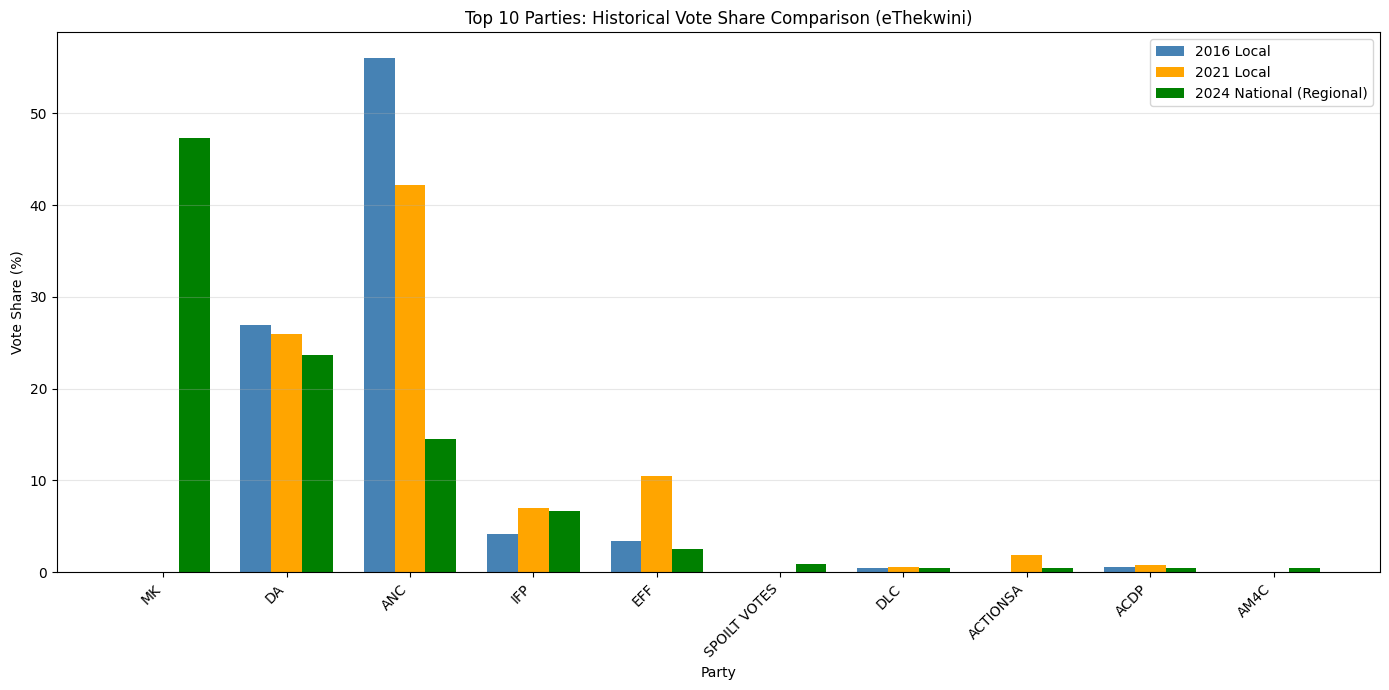

In [120]:
# ==========================================
# TOP 10 PARTIES BY 2024 VOTE SHARE
# ==========================================

top10 = df_master.sort_values("Pct_2024", ascending=False).head(10)

x = np.arange(len(top10))
width = 0.25

fig, ax = plt.subplots(figsize=(14, 7))

ax.bar(x - width, top10["Pct_2016"] * 100, width, label="2016 Local", color="steelblue")
ax.bar(x,          top10["Pct_2021"] * 100, width, label="2021 Local", color="orange")
ax.bar(x + width,  top10["Pct_2024"] * 100, width, label="2024 National (Regional)", color="green")

ax.set_xlabel("Party")
ax.set_ylabel("Vote Share (%)")
ax.set_title("Top 10 Parties: Historical Vote Share Comparison (eThekwini)")
ax.set_xticks(x)
ax.set_xticklabels(top10["Party_Std"], rotation=45, ha="right")
ax.legend()
ax.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.show()

Bar graph: 2024 vote share

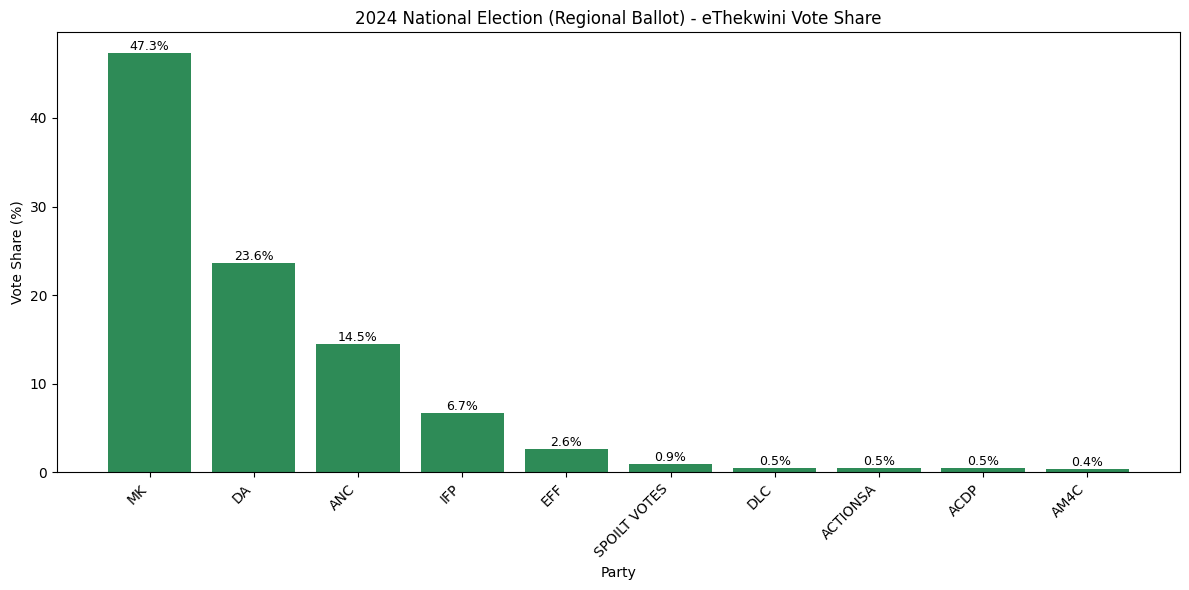

In [121]:
top10_2024 = df_master.sort_values("Pct_2024", ascending=False).head(10)

plt.figure(figsize=(12, 6))

bars = plt.bar(
    top10_2024["Party_Std"],
    top10_2024["Pct_2024"] * 100,
    color="seagreen"
)

plt.title("2024 National Election (Regional Ballot) - eThekwini Vote Share")
plt.xlabel("Party")
plt.ylabel("Vote Share (%)")
plt.xticks(rotation=45, ha="right")

for bar, value in zip(bars, top10_2024["Pct_2024"] * 100):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height(),
        f"{value:.1f}%",
        ha="center", va="bottom", fontsize=9
    )

plt.tight_layout()
plt.show()

2021 vs 2024 vote share scatter

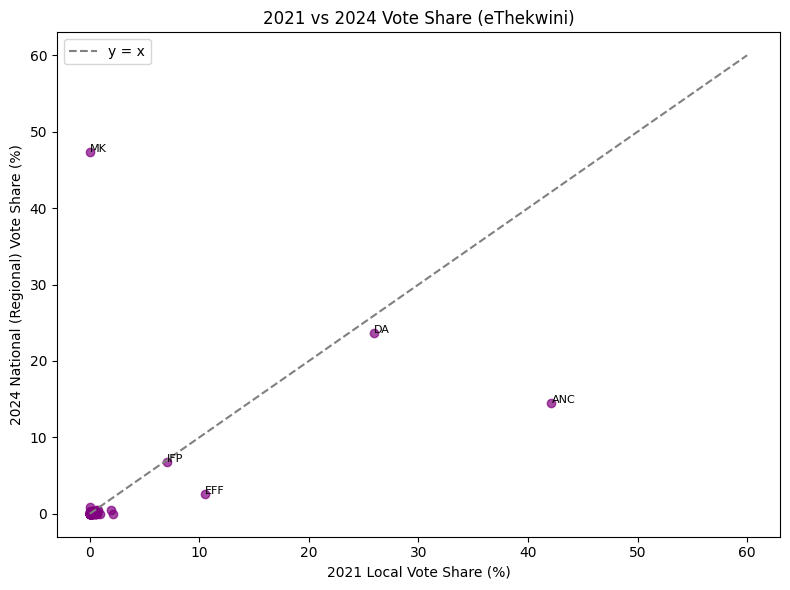

In [122]:
plt.figure(figsize=(8, 6))

plt.scatter(
    df_master["Pct_2021"] * 100,
    df_master["Pct_2024"] * 100,
    alpha=0.7,
    color="purple"
)

for _, row in df_master.iterrows():
    if row["Pct_2024"] > 0.03 or row["Pct_2021"] > 0.03:
        plt.annotate(
            row["Party_Std"],
            (row["Pct_2021"] * 100, row["Pct_2024"] * 100),
            fontsize=8
        )

plt.plot([0, 60], [0, 60], linestyle="--", color="grey", label="y = x")

plt.title("2021 vs 2024 Vote Share (eThekwini)")
plt.xlabel("2021 Local Vote Share (%)")
plt.ylabel("2024 National (Regional) Vote Share (%)")
plt.legend()
plt.tight_layout()
plt.show()

Average vote share across years

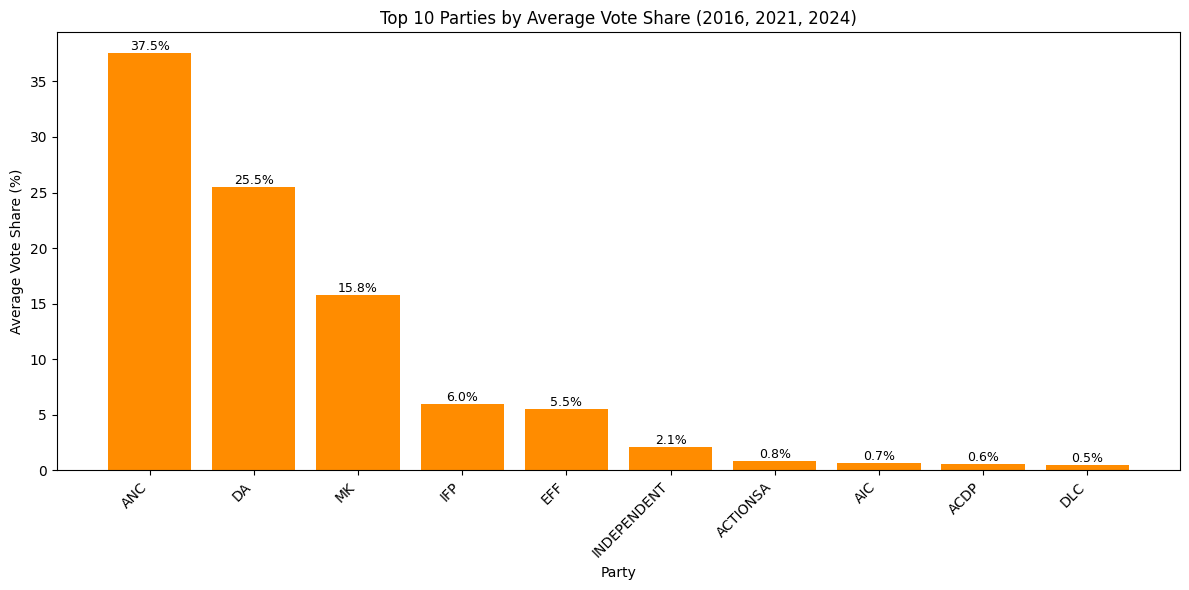

In [123]:
df_master["Avg_Pct"] = df_master[["Pct_2016", "Pct_2021", "Pct_2024"]].mean(axis=1)

avg_top10 = df_master.sort_values("Avg_Pct", ascending=False).head(10)

plt.figure(figsize=(12, 6))

bars = plt.bar(
    avg_top10["Party_Std"],
    avg_top10["Avg_Pct"] * 100,
    color="darkorange"
)

plt.title("Top 10 Parties by Average Vote Share (2016, 2021, 2024)")
plt.xlabel("Party")
plt.ylabel("Average Vote Share (%)")
plt.xticks(rotation=45, ha="right")

for bar, value in zip(bars, avg_top10["Avg_Pct"] * 100):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height(),
        f"{value:.1f}%",
        ha="center", va="bottom", fontsize=9
    )

plt.tight_layout()
plt.show()

Correlation

In [125]:
numeric_cols = ["Pct_2016", "Pct_2021", "Pct_2024"]

correlation = df_master[numeric_cols].corr()
print(correlation)

          Pct_2016  Pct_2021  Pct_2024
Pct_2016  1.000000  0.979101  0.405086
Pct_2021  0.979101  1.000000  0.430736
Pct_2024  0.405086  0.430736  1.000000


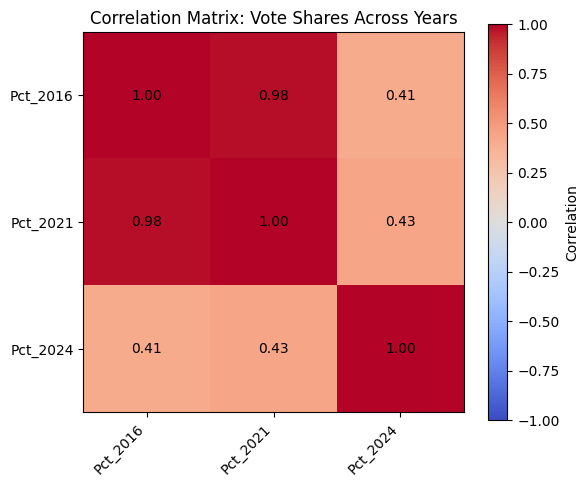

In [126]:
plt.figure(figsize=(6, 5))

plt.imshow(correlation, cmap="coolwarm", interpolation="nearest", vmin=-1, vmax=1)
plt.colorbar(label="Correlation")

plt.xticks(range(len(correlation.columns)), correlation.columns, rotation=45, ha="right")
plt.yticks(range(len(correlation.columns)), correlation.columns)

plt.title("Correlation Matrix: Vote Shares Across Years")

for i in range(len(correlation)):
    for j in range(len(correlation)):
        plt.text(j, i, f"{correlation.iloc[i, j]:.2f}", ha="center", va="center")

plt.tight_layout()
plt.show()

SPATIAL GRAPHS FOR WARDS in 2016

KeyError: 'WardNo'

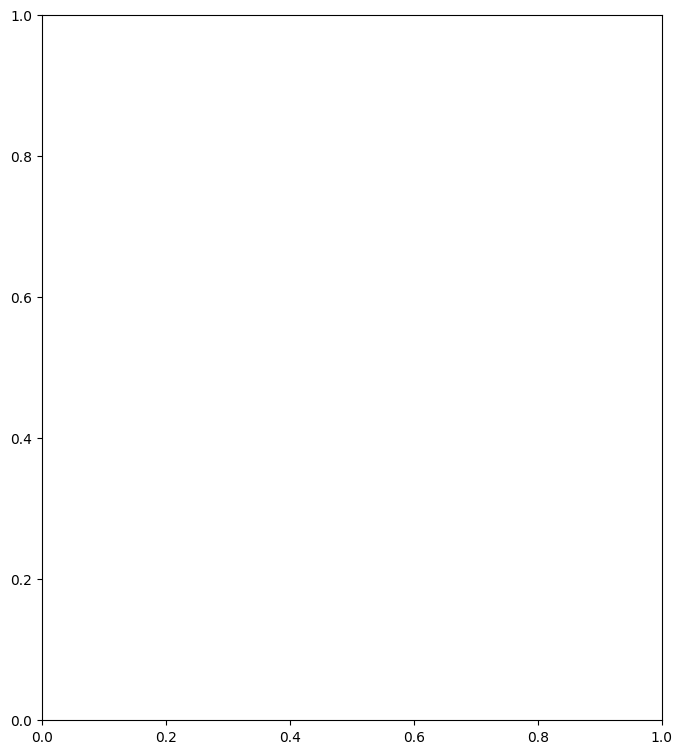

In [149]:
import matplotlib.pyplot as plt
import geopandas as gpd

# Load ward boundary GeoJSON or Shapefile
wards = gpd.read_file("MDBWard2016.geojson")
wards.head()

# Quick spatial plot of ward boundaries
fig, ax = plt.subplots(figsize=(8, 10))
wards.plot(
    ax=ax,
    column="WardNo",  # or "WardID" / party column depending on your dataset
    cmap="tab20",  # distinct color palette for wards
    legend=False,
    edgecolor="black",
    linewidth=0.5,
)

plt.title("eThekwini Ward Boundaries (2021)")
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.show()

# Filter for specific wards (e.g., selecting selected wards for analysis)
selected_wards = wards[wards["WardNo"].isin([1, 10, 20])]

SPATIAL GRAPHS FOR WARDS in 2021

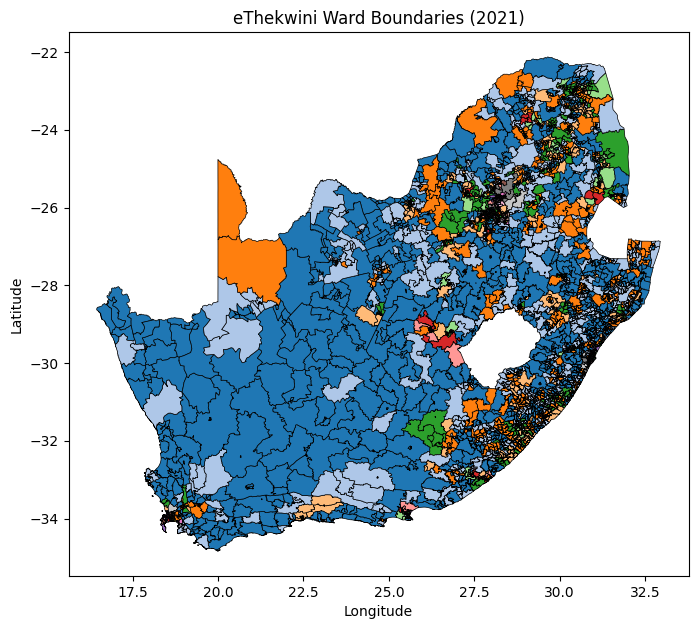

In [150]:
import matplotlib.pyplot as plt
import geopandas as gpd

# Load ward boundary GeoJSON or Shapefile
wards = gpd.read_file("MDBWard2021.geojson")
wards.head()

# Quick spatial plot of ward boundaries
fig, ax = plt.subplots(figsize=(8, 10))
wards.plot(
    ax=ax,
    column="WardNo",  # or "WardID" / party column depending on your dataset
    cmap="tab20",  # distinct color palette for wards
    legend=False,
    edgecolor="black",
    linewidth=0.5,
)

plt.title("eThekwini Ward Boundaries (2021)")
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.show()

# Filter for specific wards (e.g., selecting selected wards for analysis)
selected_wards = wards[wards["WardNo"].isin([1, 10, 20])]

SPATIAL GRAPHS FOR ethekwini wards WARDS in 2016

Total wards: 4468  |  Durban subset wards: 153


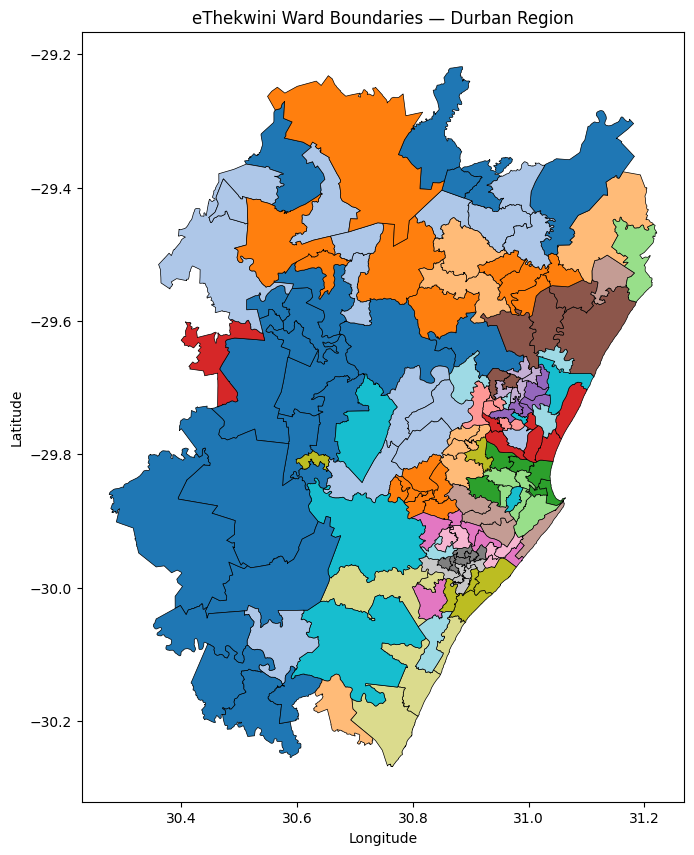

In [152]:
import geopandas as gpd
import matplotlib.pyplot as plt

# ---- Spatial bounding-box crop for eThekwini ward boundaries ----
# Crop using coordinate bounds: [minx, miny, maxx, maxy] -> [lon_min, lat_min, lon_max, lat_max]
durban_wards = wards.cx[30.5:31.15, -30.15:-29.4]

print(f"Total wards: {len(wards)}  |  Durban subset wards: {len(durban_wards)}")
# Print count of wards or distribution if a party/leading category column exists
if "LeadingParty" in durban_wards.columns:
    print(durban_wards["LeadingParty"].value_counts())

# ---- Spatial choropleth plot of cropped Durban wards ----
fig, ax = plt.subplots(figsize=(8, 10))
durban_wards.plot(
    ax=ax,
    column="WardNo",  # Or 'LeadingParty' / 'Party' to color by political leader
    cmap="tab20",  # Or categorical map if coloring by party
    edgecolor="black",
    linewidth=0.5,
    legend=False,
)
plt.title("eThekwini Ward Boundaries — Durban Region")
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.show()

# ---- Filter by ward criteria / do further spatial ops on the Durban ward subset ----
# Example: Select specific wards by Ward Number for analysis
selected_wards = durban_wards[durban_wards["WardNo"].isin([1, 10, 20])]

SPATIAL GRAPHS FOR ethekwini wards WARDS in 2016

Total wards: 4468  |  Durban subset wards: 153


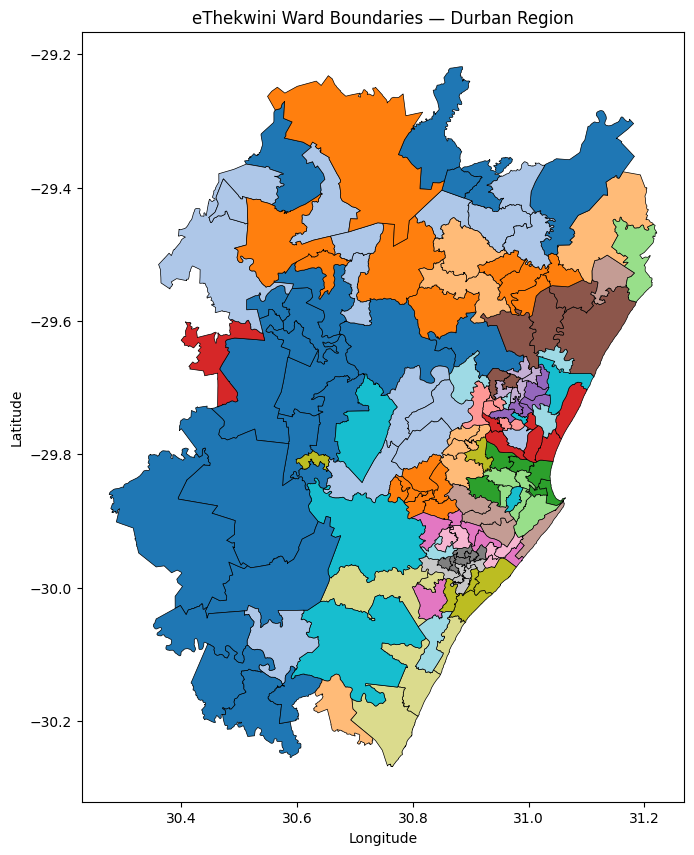

In [151]:
import geopandas as gpd
import matplotlib.pyplot as plt

# ---- Spatial bounding-box crop for eThekwini ward boundaries ----
# Crop using coordinate bounds: [minx, miny, maxx, maxy] -> [lon_min, lat_min, lon_max, lat_max]
durban_wards = wards.cx[30.5:31.15, -30.15:-29.4]

print(f"Total wards: {len(wards)}  |  Durban subset wards: {len(durban_wards)}")
# Print count of wards or distribution if a party/leading category column exists
if "LeadingParty" in durban_wards.columns:
    print(durban_wards["LeadingParty"].value_counts())

# ---- Spatial choropleth plot of cropped Durban wards ----
fig, ax = plt.subplots(figsize=(8, 10))
durban_wards.plot(
    ax=ax,
    column="WardNo",  # Or 'LeadingParty' / 'Party' to color by political leader
    cmap="tab20",  # Or categorical map if coloring by party
    edgecolor="black",
    linewidth=0.5,
    legend=False,
)
plt.title("eThekwini Ward Boundaries — Durban Region")
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.show()

# ---- Filter by ward criteria / do further spatial ops on the Durban ward subset ----
# Example: Select specific wards by Ward Number for analysis
selected_wards = durban_wards[durban_wards["WardNo"].isin([1, 10, 20])]

Prepare the Data

FEATURES AND TARGET

Filter to parties with meaningful presence (>= 0.1% in at least one year)

In [127]:
df_model = df_master[
    (df_master["Pct_2016"] >= 0.001) |
    (df_master["Pct_2021"] >= 0.001) |
    (df_master["Pct_2024"] >= 0.001)
].copy()

print("Parties included for modelling:", len(df_model))

Parties included for modelling: 39


Features: historical vote shares

In [129]:
X = df_model[["Pct_2016", "Pct_2021"]]

Target: 2024 vote share (proxy for 2026 projection)

In [130]:
y = df_model["Pct_2024"]

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (39, 2)
y shape: (39,)


Train/Test Split

In [131]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42
)

print("Training data:", X_train.shape)
print("Testing data:", X_test.shape)

Training data: (31, 2)
Testing data: (8, 2)


Train the ML Models

In [132]:
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, r2_score

Create the models

In [133]:
models = {
    "Linear Regression": LinearRegression(),
    "Ridge Regression": Ridge(alpha=1.0),
    "Random Forest": RandomForestRegressor(
        n_estimators=200, max_depth=5, min_samples_split=3,
        random_state=42, n_jobs=-1
    ),
    "Gradient Boosting": GradientBoostingRegressor(
        n_estimators=200, max_depth=3, learning_rate=0.05,
        random_state=42
    )
}

Train and test all models

In [134]:
results = []

for name, model in models.items():
    print(f"\nTraining {name}...")
    model.fit(X_train, y_train)

    train_pred = model.predict(X_train)
    test_pred = model.predict(X_test)

    train_r2 = r2_score(y_train, train_pred)
    test_r2 = r2_score(y_test, test_pred)
    test_mae = mean_absolute_error(y_test, test_pred)

    results.append({
        "Model": name,
        "Train R2": train_r2,
        "Test R2": test_r2,
        "Test MAE": test_mae
    })

    print(f"  Train R2: {train_r2:.4f}")
    print(f"  Test R2:  {test_r2:.4f}")
    print(f"  Test MAE: {test_mae:.4f}")


Training Linear Regression...
  Train R2: 0.8021
  Test R2:  -0.1590
  Test MAE: 0.0618

Training Ridge Regression...
  Train R2: 0.4249
  Test R2:  -0.0977
  Test MAE: 0.0668

Training Random Forest...
  Train R2: 0.8920
  Test R2:  -0.1224
  Test MAE: 0.0599

Training Gradient Boosting...
  Train R2: 0.9999
  Test R2:  -0.1094
  Test MAE: 0.0603


In [135]:
results_df = pd.DataFrame(results)
print("\n===== MODEL RESULTS =====")
print(results_df.round(4))


===== MODEL RESULTS =====
               Model  Train R2  Test R2  Test MAE
0  Linear Regression    0.8021  -0.1590    0.0618
1   Ridge Regression    0.4249  -0.0977    0.0668
2      Random Forest    0.8920  -0.1224    0.0599
3  Gradient Boosting    0.9999  -0.1094    0.0603


Predict 2026 Vote Shares

In [136]:
# PROJECT 2026 VOTE SHARES

best_model = models["Random Forest"]

# Use 2021 and 2024 as the most recent historical features
X_2026 = df_model[["Pct_2021", "Pct_2024"]].copy()
X_2026.columns = ["Pct_2016", "Pct_2021"]  # match training feature names

df_model["Pct_2026_Predicted"] = best_model.predict(X_2026)

# Normalise to sum to 1
df_model["Pct_2026_Predicted"] = (
    df_model["Pct_2026_Predicted"] /
    df_model["Pct_2026_Predicted"].sum()
)

projected_top = df_model.sort_values("Pct_2026_Predicted", ascending=False).head(10)
print(projected_top[["Party_Std", "Pct_2021", "Pct_2024", "Pct_2026_Predicted"]])

      Party_Std  Pct_2021  Pct_2024  Pct_2026_Predicted
28           DA  0.259496  0.236257            0.305174
16          ANC  0.421373  0.144751            0.231695
47           MK  0.000000  0.472929            0.196789
38          IFP  0.070577  0.067270            0.091326
31          EFF  0.104754  0.025867            0.026316
68          UPP  0.000000  0.000000            0.011006
39  INDEPENDENT  0.021272  0.000000            0.008828
8           ADC  0.005052  0.000000            0.007109
46           MF  0.004876  0.000000            0.007109
43          JEP  0.005624  0.000000            0.006810


Visualise 2026 projection

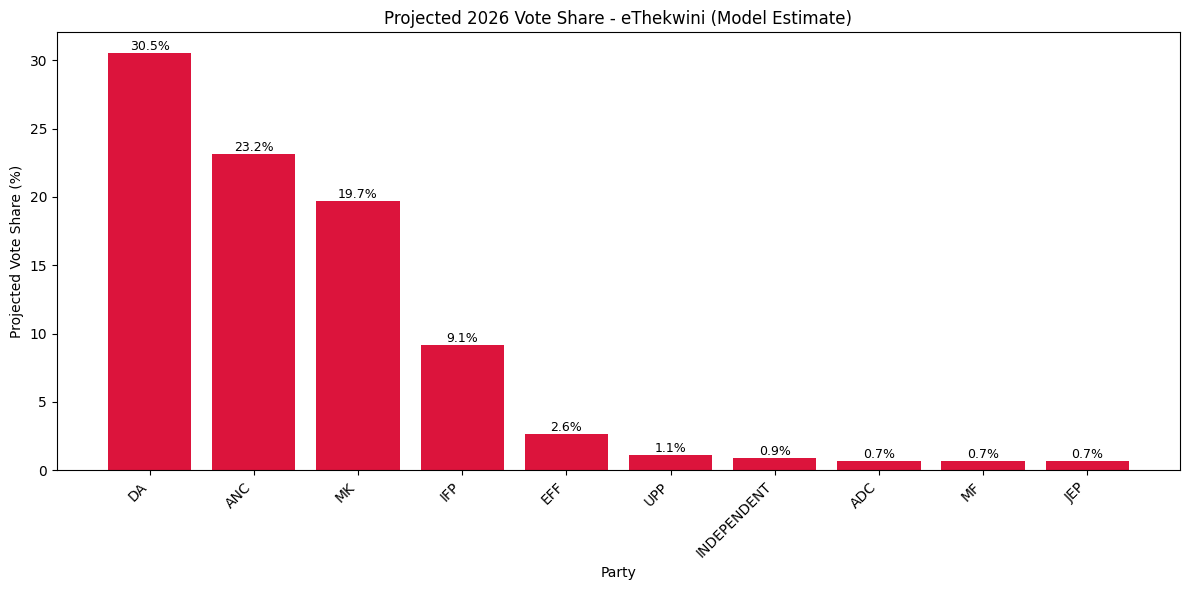

In [137]:
plt.figure(figsize=(12, 6))

bars = plt.bar(
    projected_top["Party_Std"],
    projected_top["Pct_2026_Predicted"] * 100,
    color="crimson"
)

plt.title("Projected 2026 Vote Share - eThekwini (Model Estimate)")
plt.xlabel("Party")
plt.ylabel("Projected Vote Share (%)")
plt.xticks(rotation=45, ha="right")

for bar, value in zip(bars, projected_top["Pct_2026_Predicted"] * 100):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height(),
        f"{value:.1f}%",
        ha="center", va="bottom", fontsize=9
    )

plt.tight_layout()
plt.show()

Projected Voter Turnout for 2026

In [138]:
# ==========================================
# PROJECTED VOTER TURNOUT
# ==========================================

registered_2024 = 1989823  # from 2024 National sheet

total_valid_2016 = party_rows_2016_agg["Total_All_Ballots"].sum()
total_valid_2021 = party_rows_2021_agg["Total_All_Ballots"].sum()
total_valid_2024 = d2024_agg["Votes"].sum()

turnout_2016 = total_valid_2016 / registered_2024
turnout_2021 = total_valid_2021 / registered_2024
turnout_2024 = total_valid_2024 / registered_2024

print(f"2016 Turnout (approx): {turnout_2016:.2%}")
print(f"2021 Turnout (approx): {turnout_2021:.2%}")
print(f"2024 Turnout (approx): {turnout_2024:.2%}")

years = np.array([2016, 2021, 2024]).reshape(-1, 1)
turnouts = np.array([turnout_2016, turnout_2021, turnout_2024])

turnout_model = LinearRegression()
turnout_model.fit(years, turnouts)

turnout_2026 = turnout_model.predict([[2026]])[0]

print(f"\nProjected 2026 Turnout Rate: {turnout_2026:.2%}")
print(f"Projected 2026 Votes Cast: {int(turnout_2026 * registered_2024):,}")

2016 Turnout (approx): 111.85%
2021 Turnout (approx): 77.93%
2024 Turnout (approx): 62.62%

Projected 2026 Turnout Rate: 48.90%
Projected 2026 Votes Cast: 972,964


Visualise turnout trend

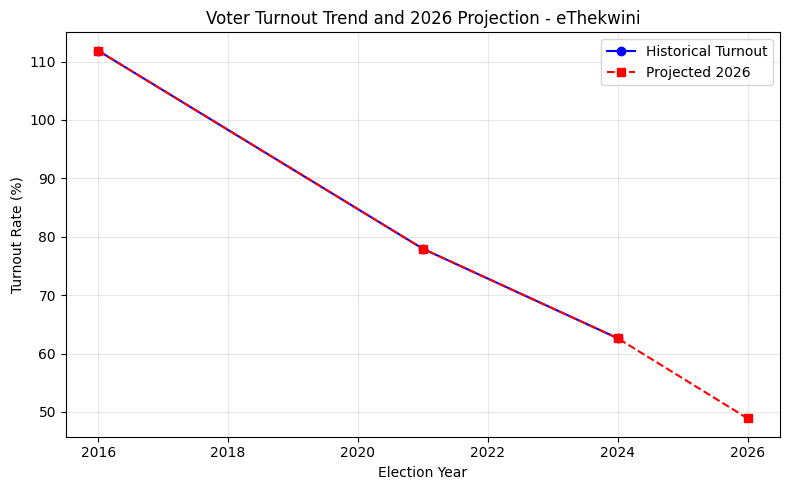

In [139]:
plt.figure(figsize=(8, 5))

plt.plot(years.flatten(), turnouts * 100, marker="o", label="Historical Turnout", color="blue")
plt.plot([2016, 2021, 2024, 2026],
         [turnout_2016 * 100, turnout_2021 * 100, turnout_2024 * 100, turnout_2026 * 100],
         marker="s", linestyle="--", label="Projected 2026", color="red")

plt.title("Voter Turnout Trend and 2026 Projection - eThekwini")
plt.xlabel("Election Year")
plt.ylabel("Turnout Rate (%)")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

Projected Vote Totals for 2026

In [140]:
# PROJECTED 2026 VOTE TOTALS

projected_votes_2026 = int(turnout_2026 * registered_2024)

df_model["Projected_Votes_2026"] = (
    df_model["Pct_2026_Predicted"] * projected_votes_2026
).round(0).astype(int)

projected_votes_top = df_model.sort_values("Pct_2026_Predicted", ascending=False).head(10)

print("Projected 2026 Vote Totals (Top 10):")
print(projected_votes_top[["Party_Std", "Pct_2026_Predicted", "Projected_Votes_2026"]])

Projected 2026 Vote Totals (Top 10):
      Party_Std  Pct_2026_Predicted  Projected_Votes_2026
28           DA            0.305174                296923
16          ANC            0.231695                225431
47           MK            0.196789                191469
38          IFP            0.091326                 88857
31          EFF            0.026316                 25605
68          UPP            0.011006                 10709
39  INDEPENDENT            0.008828                  8589
8           ADC            0.007109                  6916
46           MF            0.007109                  6916
43          JEP            0.006810                  6626


Bar chart: projected vote totals

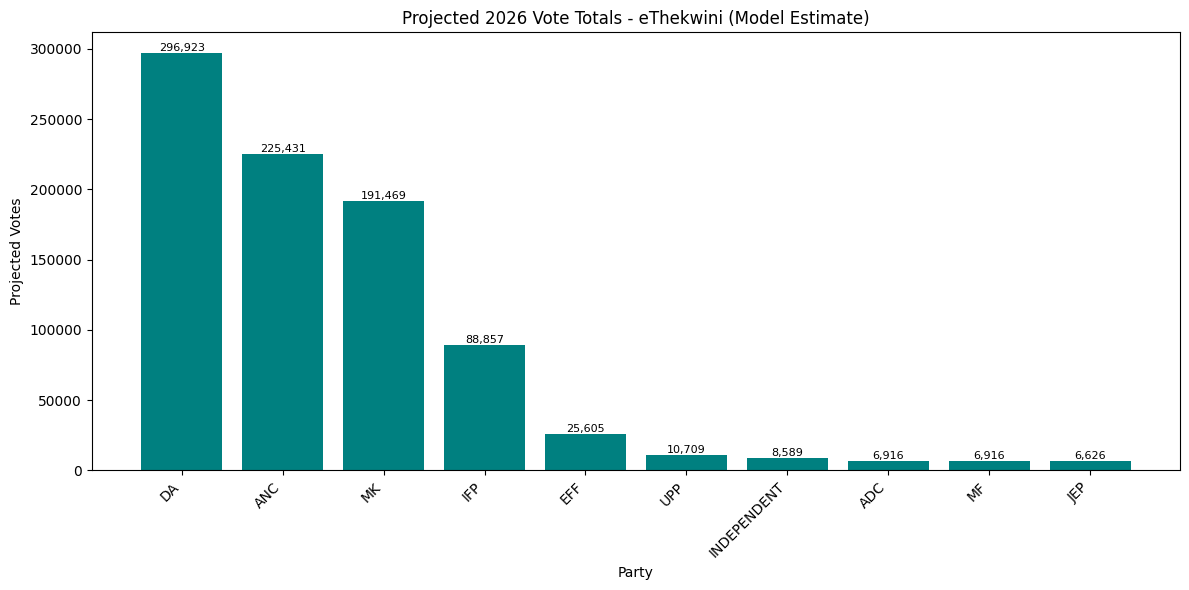

In [141]:
plt.figure(figsize=(12, 6))

bars = plt.bar(
    projected_votes_top["Party_Std"],
    projected_votes_top["Projected_Votes_2026"],
    color="teal"
)

plt.title("Projected 2026 Vote Totals - eThekwini (Model Estimate)")
plt.xlabel("Party")
plt.ylabel("Projected Votes")
plt.xticks(rotation=45, ha="right")

for bar, value in zip(bars, projected_votes_top["Projected_Votes_2026"]):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height(),
        f"{int(value):,}",
        ha="center", va="bottom", fontsize=8
    )

plt.tight_layout()
plt.show()

Coalition Analysis

In [142]:
# COALITION SCENARIO ANALYSIS

df_coalition = df_model.sort_values("Pct_2026_Predicted", ascending=False).reset_index(drop=True)

majority_party = df_coalition[df_coalition["Pct_2026_Predicted"] > 0.50]

if len(majority_party) > 0:
    print(f"Outright majority projected for: {majority_party.iloc[0]['Party_Std']}")
else:
    print("No outright majority projected. Coalition required.")

    cumulative = 0
    coalition = []
    for _, row in df_coalition.iterrows():
        coalition.append(row["Party_Std"])
        cumulative += row["Pct_2026_Predicted"]
        if cumulative > 0.50:
            break

    print("\nMinimal winning coalition (top-down):")
    for p in coalition:
        pct = df_coalition[df_coalition["Party_Std"] == p]["Pct_2026_Predicted"].values[0]
        print(f"  {p}: {pct * 100:.2f}%")
    print(f"  Total: {cumulative * 100:.2f}%")

No outright majority projected. Coalition required.

Minimal winning coalition (top-down):
  DA: 30.52%
  ANC: 23.17%
  Total: 53.69%


Feature Importance

    Feature  Importance
1  Pct_2021    0.533797
0  Pct_2016    0.466203


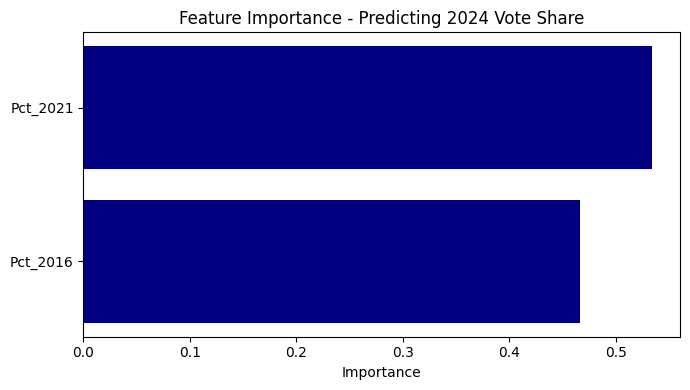

In [143]:
# FEATURE IMPORTANCE - RANDOM FOREST

rf_model = models["Random Forest"]
importance = rf_model.feature_importances_

feature_importance = pd.DataFrame({
    "Feature": X_train.columns,
    "Importance": importance
}).sort_values("Importance", ascending=False)

print(feature_importance)

plt.figure(figsize=(7, 4))
plt.barh(feature_importance["Feature"], feature_importance["Importance"], color="navy")
plt.title("Feature Importance - Predicting 2024 Vote Share")
plt.xlabel("Importance")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

Model Validation

ACTUAL VS PREDICTED - 2024 (VALIDATION)

In [144]:
y_pred_rf = rf_model.predict(X_test)

result = pd.DataFrame({
    "Party": df_model.loc[y_test.index, "Party_Std"].values,
    "Actual_Pct_2024": y_test.values * 100,
    "Predicted_Pct_2024": y_pred_rf * 100
})

result["Error"] = result["Actual_Pct_2024"] - result["Predicted_Pct_2024"]

print(result.round(3))

        Party  Actual_Pct_2024  Predicted_Pct_2024   Error
0        RISE            0.213               0.565  -0.352
1         UIM            0.078               0.064   0.015
2         ADC            0.000               0.080  -0.080
3        BOSA            0.201               0.565  -0.364
4         PAC            0.110               0.100   0.010
5          MK           47.293               0.565  46.728
6  AL JAMA-AH            0.366               0.029   0.337
7        MOSA            0.000               0.037  -0.037


Scatter: actual vs predicted

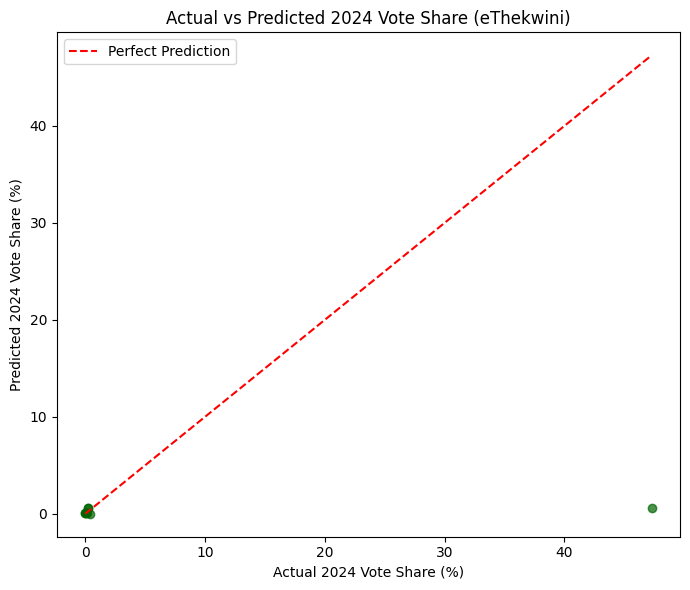

In [145]:
plt.figure(figsize=(7, 6))

plt.scatter(
    result["Actual_Pct_2024"],
    result["Predicted_Pct_2024"],
    alpha=0.7,
    color="darkgreen"
)

plt.plot([0, result["Actual_Pct_2024"].max()],
         [0, result["Actual_Pct_2024"].max()],
         linestyle="--", color="red", label="Perfect Prediction")

plt.title("Actual vs Predicted 2024 Vote Share (eThekwini)")
plt.xlabel("Actual 2024 Vote Share (%)")
plt.ylabel("Predicted 2024 Vote Share (%)")
plt.legend()
plt.tight_layout()
plt.show()

Save the Model

In [157]:
import joblib

model_data = {
    "model": rf_model,
    "features": X_train.columns.tolist()
}

joblib.dump(model_data, "election_2026_forecast_model.pkl")
print("Election forecasting model saved successfully.")

Election forecasting model saved successfully.


Load the model

In [158]:
import joblib

model_data = joblib.load("election_2026_forecast_model.pkl")
loaded_model = model_data["model"]
feature_names = model_data["features"]

print("Model loaded successfully.")
print("Features:", feature_names)

Model loaded successfully.
Features: ['Pct_2016', 'Pct_2021']


Forecasting Summary

In [159]:

print("=" * 60)
print("2026 eThekwini Election Forecast Summary")
print("=" * 60)

print(f"\nRegistered Voters (2024 baseline): {registered_2024:,}")
print(f"Projected 2026 Turnout Rate: {turnout_2026:.2%}")
print(f"Projected 2026 Votes Cast: {projected_votes_2026:,}")

print("\nProjected Vote Shares (Top 5):")
top5 = df_model.sort_values("Pct_2026_Predicted", ascending=False).head(5)
for _, row in top5.iterrows():
    print(f"  {row['Party_Std']}: {row['Pct_2026_Predicted'] * 100:.2f}% "
          f"({row['Projected_Votes_2026']:,} votes)")


2026 eThekwini Election Forecast Summary

Registered Voters (2024 baseline): 1,989,823
Projected 2026 Turnout Rate: 48.90%
Projected 2026 Votes Cast: 972,964

Projected Vote Shares (Top 5):
  DA: 30.52% (296,923 votes)
  ANC: 23.17% (225,431 votes)
  MK: 19.68% (191,469 votes)
  IFP: 9.13% (88,857 votes)
  EFF: 2.63% (25,605 votes)

Note: These are model estimates with inherent uncertainty.
They are NOT predictions of actual election outcomes.
